# GP AI, Système d'aide à la décision pour l'orientation diagnostique des troubles génétiques chez l'enfant



1. Analyse des données
2. Nettoyage des données
3. Imputation des valeurs manquantes restantes
4. Visualisation : médiane, moyenne et dispersion
5. Export du dataset nettoyé


<a id="sec-1"></a>
# 1. Analyse des données

In [25]:
import pandas as pd
df = pd.read_csv('genetic_disorders_pediatric_v2.csv')

df

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Institute Name,...,Genetic panel status,Maternal gene name,Paternal gene name,Hypotonie musculaire,Retard de croissance,Convulsions,Detresse respiratoire,Regression neurologique,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,No,No,4.760603,NaN,NaN,Boston Specialty & Rehabilitation Hospital,...,Non realise,Non realise,Non realise,1,0,1,1,0,Mitochondrial genetic inheritance disorders,MELAS syndrome
1,PID0x25d5,4.0,Yes,Yes,Yes,Yes,4.910669,NaN,23.0,St. Margaret's Hospital For Women,...,Non concluant,Non concluant,Non concluant,0,1,0,1,0,Single-gene inheritance diseases,Cystic fibrosis
2,PID0x4a82,6.0,No,Yes,Yes,No,4.893297,41.0,22.0,NaN,...,Non realise,Non realise,Non realise,1,1,0,0,0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,21.0,NaN,NaN,...,Non realise,Non realise,Non realise,1,0,1,1,0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,No,Yes,No,Yes,4.720703,32.0,NaN,Carney Hospital,...,Realise,NKX2-5,Aucun,0,1,0,1,0,Multifactorial genetic inheritance disorders,Congenital heart defect
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18938,PID0x353b,2.0,Yes,No,Yes,No,5.144151,19.0,42.0,Not applicable,...,Realise,MT-TK,Aucun,1,0,0,0,0,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy
18939,PID0x26c,11.0,Yes,No,No,Yes,5.090495,46.0,NaN,Brigham And Women's Hospital,...,Non realise,Non realise,Non realise,1,1,1,0,0,Single-gene inheritance diseases,Tay-Sachs
18940,PID0xa01,NaN,Yes,No,Yes,No,5.214750,NaN,38.0,NaN,...,Non concluant,Non concluant,Non concluant,1,0,1,0,1,Mitochondrial genetic inheritance disorders,Leigh syndrome
18941,PID0x8d32,1.0,Yes,No,Yes,No,5.224828,33.0,24.0,Not applicable,...,Realise,MT-ND1,Aucun,1,0,0,1,0,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18943 entries, 0 to 18942
Data columns (total 36 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Id                                        18943 non-null  object 
 1   Patient Age                                       17752 non-null  float64
 2   Genes in mother's side                            18943 non-null  object 
 3   Inherited from father                             18943 non-null  object 
 4   Maternal gene                                     18943 non-null  object 
 5   Paternal gene                                     18943 non-null  object 
 6   Blood cell count (mcL)                            18943 non-null  float64
 7   Mother's age                                      14018 non-null  float64
 8   Father's age                                      14081 non-null  float64
 9   Institute Name   

In [27]:
missing_values = df.isnull().sum()
pourcentage_missing = (missing_values / len(df)) * 100
print("Pourcentage de valeurs manquantes par colonne :")
print(pourcentage_missing)

Pourcentage de valeurs manquantes par colonne :
Patient Id                                           0.000000
Patient Age                                          6.287283
Genes in mother's side                               0.000000
Inherited from father                                0.000000
Maternal gene                                        0.000000
Paternal gene                                        0.000000
Blood cell count (mcL)                               0.000000
Mother's age                                        25.999050
Father's age                                        25.666473
Institute Name                                      21.923666
Location of Institute                                0.000000
Respiratory Rate (breaths/min)                       9.401890
Heart Rate (rates/min                                9.048197
Gender                                               9.327984
Birth asphyxia                                       9.196009
Place of birth        

<a id="sec-2"></a>
# 2. Nettoyage des données

In [28]:
# Supprimer les colonnes inutiles
df = df.drop(columns=[
    'Patient Id', 'Institute Name', 'Location of Institute', 'Genetic Disorder',
    "Genes in mother's side", 'Inherited from father',
], errors='ignore')
df.shape

(18943, 30)

In [29]:
# Traduction de toutes les colonnes en français
df = df.rename(columns={
    'Patient Age': 'Âge du patient (années)',
    'Maternal gene': 'Gène maternel',
    'Paternal gene': 'Gène paternel',
    'Blood cell count (mcL)': 'Numération des globules rouges (mcL)',
    "Mother's age": 'Âge de la mère',
    "Father's age": 'Âge du père',
    'Respiratory Rate (breaths/min)': 'Fréquence respiratoire',
    'Heart Rate (rates/min': 'Fréquence cardiaque',
    'Gender': 'Sexe',
    'Birth asphyxia': 'Asphyxie à la naissance',
    'Place of birth': 'Lieu de naissance',
    'Folic acid details (peri-conceptional)': "Prise d'acide folique périconceptionnelle",
    'H/O serious maternal illness': 'Antécédent de maladie maternelle grave',
    'H/O radiation exposure (x-ray)': "Antécédent d'exposition aux radiations (rayons X)",
    'H/O substance abuse': 'Antécédent de toxicomanie',
    'Assisted conception IVF/ART': 'Conception assistée (FIV/PMA)',
    'History of anomalies in previous pregnancies': "Antécédents d'anomalies lors de grossesses précédentes",
    'No. of previous abortion': "Nombre d'avortements antérieurs",
    'Birth defects': 'Malformations congénitales',
    'White Blood cell count (thousand per microliter)': 'Numération des globules blancs (milliers/µL)',
    'Blood test result': 'Résultat du bilan sanguin',
    'Genetic panel status': 'Statut du panel génétique',
    'Maternal gene name': 'Nom du gène maternel',
    'Paternal gene name': 'Nom du gène paternel',
    'Detresse respiratoire': 'Détresse respiratoire',
    'Regression neurologique': 'Régression neurologique',
    'Disorder Subclass': 'Sous-classe diagnostique',
})
df.columns.tolist()

['Âge du patient (années)',
 'Gène maternel',
 'Gène paternel',
 'Numération des globules rouges (mcL)',
 'Âge de la mère',
 'Âge du père',
 'Fréquence respiratoire',
 'Fréquence cardiaque',
 'Sexe',
 'Asphyxie à la naissance',
 'Lieu de naissance',
 "Prise d'acide folique périconceptionnelle",
 'Antécédent de maladie maternelle grave',
 "Antécédent d'exposition aux radiations (rayons X)",
 'Antécédent de toxicomanie',
 'Conception assistée (FIV/PMA)',
 "Antécédents d'anomalies lors de grossesses précédentes",
 "Nombre d'avortements antérieurs",
 'Malformations congénitales',
 'Numération des globules blancs (milliers/µL)',
 'Résultat du bilan sanguin',
 'Statut du panel génétique',
 'Nom du gène maternel',
 'Nom du gène paternel',
 'Hypotonie musculaire',
 'Retard de croissance',
 'Convulsions',
 'Détresse respiratoire',
 'Régression neurologique',
 'Sous-classe diagnostique']

## Traduction de toutes les valeurs en français

Les colonnes ont déjà été renommées ci-dessus ; on traduit maintenant **les valeurs** (Oui/Non, Tachypnée, Masculin/Féminin, etc.) et les **noms de maladies** de la cible, afin que l'intégralité du dataset — et donc les graphiques, le modèle et l'application — soit en français. Les symboles de gènes (CFTR, SMN1…) restent inchangés (nomenclature internationale).

In [ ]:
# Traduction en français de toutes les valeurs catégorielles (par colonne)
traductions_valeurs = {
    'Gène maternel': {'Yes': 'Oui', 'No': 'Non'},
    'Gène paternel': {'Yes': 'Oui', 'No': 'Non'},
    'Fréquence respiratoire': {'Normal (30-60)': 'Normale (30-60)', 'Tachypnea': 'Tachypnée'},
    'Fréquence cardiaque': {'Normal': 'Normale', 'Tachycardia': 'Tachycardie'},
    'Sexe': {'Ambiguous': 'Ambigu', 'Male': 'Masculin', 'Female': 'Féminin'},
    'Asphyxie à la naissance': {'Yes': 'Oui', 'No': 'Non', 'Not available': 'Non disponible', 'No record': 'Non renseigné'},
    'Lieu de naissance': {'Institute': 'Établissement', 'Home': 'Domicile'},
    "Prise d'acide folique périconceptionnelle": {'Yes': 'Oui', 'No': 'Non'},
    'Antécédent de maladie maternelle grave': {'Yes': 'Oui', 'No': 'Non'},
    "Antécédent d'exposition aux radiations (rayons X)": {'Yes': 'Oui', 'No': 'Non', 'Not applicable': 'Non applicable', '-': 'Non renseigné'},
    'Antécédent de toxicomanie': {'Yes': 'Oui', 'No': 'Non', 'Not applicable': 'Non applicable', '-': 'Non renseigné'},
    'Conception assistée (FIV/PMA)': {'Yes': 'Oui', 'No': 'Non'},
    "Antécédents d'anomalies lors de grossesses précédentes": {'Yes': 'Oui', 'No': 'Non'},
    'Malformations congénitales': {'Singular': 'Unique', 'Multiple': 'Multiples'},
    'Résultat du bilan sanguin': {'slightly abnormal': 'Légèrement anormal', 'inconclusive': 'Non concluant', 'normal': 'Normal', 'abnormal': 'Anormal'},
    'Statut du panel génétique': {'Non realise': 'Non réalisé', 'Realise': 'Réalisé'},
    'Nom du gène maternel': {'Non realise': 'Non réalisé'},
    'Nom du gène paternel': {'Non realise': 'Non réalisé'},
}
for _col, _mp in traductions_valeurs.items():
    df[_col] = df[_col].replace(_mp)

# Traduction des noms de maladies (cible)
traduction_classes = {
    'Leigh syndrome': 'Syndrome de Leigh',
    'Mitochondrial myopathy': 'Myopathie mitochondriale',
    'Cystic fibrosis': 'Mucoviscidose',
    'Tay-Sachs': 'Maladie de Tay-Sachs',
    'Diabetes': 'Diabète',
    'Spinal muscular atrophy': 'Amyotrophie spinale',
    'MELAS syndrome': 'Syndrome MELAS',
    'Neural tube defect': 'Anomalie du tube neural',
    'Congenital heart defect': 'Cardiopathie congénitale',
}
df['Sous-classe diagnostique'] = df['Sous-classe diagnostique'].replace(traduction_classes)

<a id="sec-2-1"></a>
## 3 Imputation des valeurs manquantes restantes

In [30]:
# Preuve que les valeurs imputées ne sont pas choisies au hasard : ce sont les médianes statistiques
# calculées directement sur les valeurs réellement connues de chaque variable (celles qui ne sont pas NaN).
target_cols = ['Sous-classe diagnostique']
numeric_cols_preview = df.drop(columns=target_cols).select_dtypes(include='number').columns

comparaison = df[numeric_cols_preview].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
comparaison.columns = ['Nb valeurs connues', 'Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max']
print(comparaison.round(2))

# Vérification manuelle, sans utiliser .median(), pour prouver le calcul sur l'exemple de Âge de la mère
colonne = "Âge de la mère"
valeurs_connues = df[colonne].dropna().sort_values().reset_index(drop=True)
n = len(valeurs_connues)
if n % 2 == 0:
    mediane_manuelle = (valeurs_connues[n // 2 - 1] + valeurs_connues[n // 2]) / 2
else:
    mediane_manuelle = valeurs_connues[n // 2]
mediane_pandas = df[colonne].median()

print(f"\nExemple détaillé : {colonne}")
print(f"Nombre de valeurs connues (hors NaN) : {n}")
print(f"Valeurs triées, position centrale ({n // 2}) : {mediane_manuelle}")
print(f"Résultat de pandas .median() : {mediane_pandas}")
print(f"Les deux méthodes donnent le même résultat : {mediane_manuelle == mediane_pandas}")

                                              Nb valeurs connues  Moyenne  \
Âge du patient (années)                                  17752.0     6.95   
Numération des globules rouges (mcL)                     18943.0     4.90   
Âge de la mère                                           14018.0    34.54   
Âge du père                                              14081.0    41.93   
Nombre d'avortements antérieurs                          17201.0     2.00   
Numération des globules blancs (milliers/µL)             17157.0     7.48   
Hypotonie musculaire                                     18943.0     0.64   
Retard de croissance                                     18943.0     0.64   
Convulsions                                              18943.0     0.41   
Détresse respiratoire                                    18943.0     0.48   
Régression neurologique                                  18943.0     0.49   

                                              Médiane  Écart-type    Min  \

<a id="sec-2-1-1"></a>
### 4 Visualisation : médiane, moyenne et dispersion

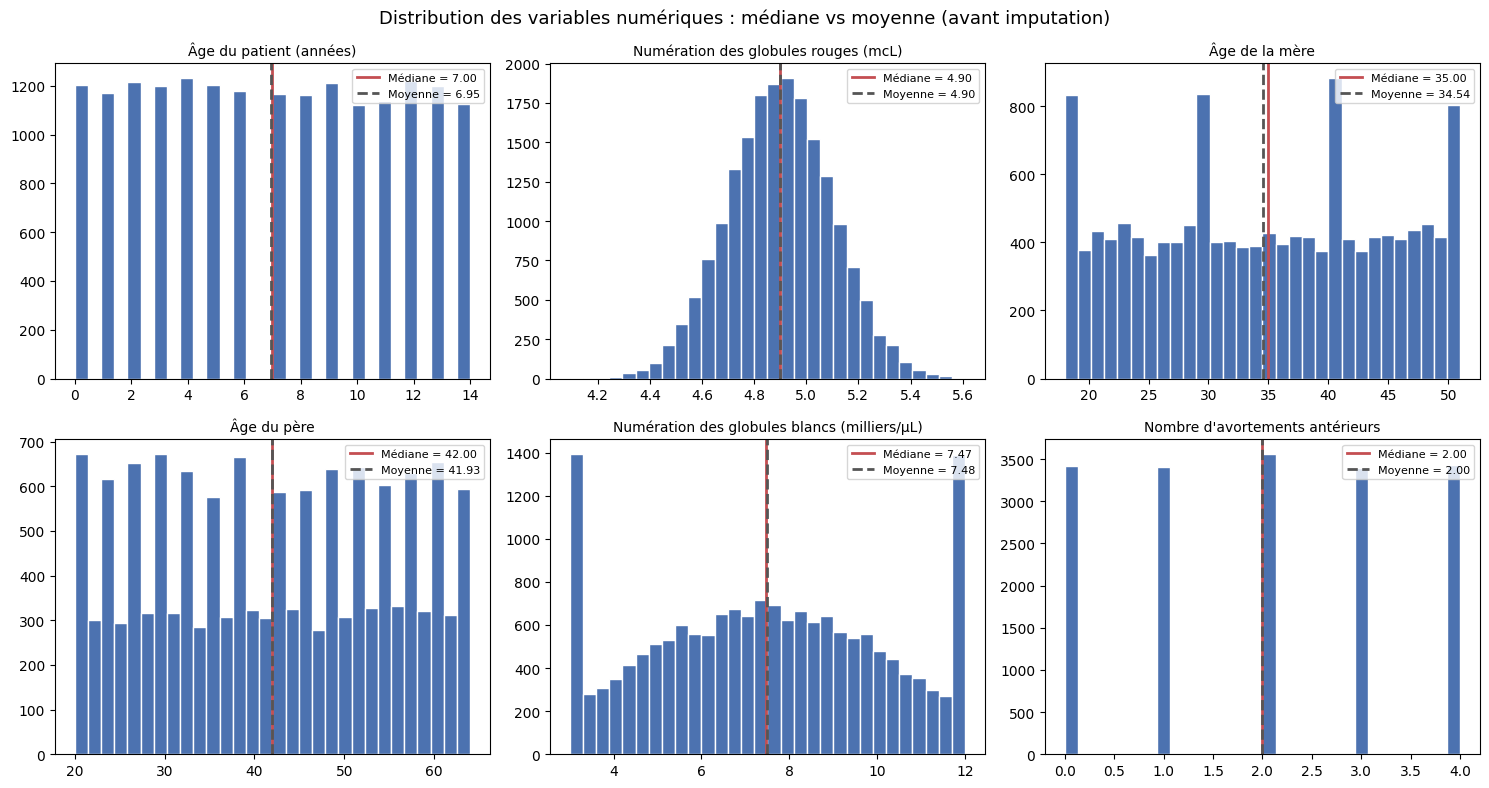

In [31]:
import matplotlib.pyplot as plt

variables_continues = ['Âge du patient (années)', 'Numération des globules rouges (mcL)', 'Âge de la mère',
                        'Âge du père', 'Numération des globules blancs (milliers/µL)', "Nombre d'avortements antérieurs"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, variables_continues):
    donnees = df[col].dropna()
    mediane = donnees.median()
    moyenne = donnees.mean()
    ax.hist(donnees, bins=30, color="#4C72B0", edgecolor="white")
    ax.axvline(mediane, color="#C44E52", linewidth=2, label=f"Médiane = {mediane:.2f}")
    ax.axvline(moyenne, color="#555555", linewidth=2, linestyle="--", label=f"Moyenne = {moyenne:.2f}")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Distribution des variables numériques : médiane vs moyenne (avant imputation)", fontsize=13)
plt.tight_layout()
plt.show()


Chaque barre indique combien d'enfants ont telle valeur. 

La ligne rouge est la médiane (la valeur du milieu), la ligne verte est la moyenne.

Pour chaque variable la moyenne et la médiane sont quasiment collées, les données sont donc équilibrées, aucune valeur extrême ne vient tirer la moyenne d'un côté.

L'âge des enfants s'étale de 0 à 14 ans de façon régulière en moyenne 7 ans.
L'âge des mères tourne autour de 35 ans et celui des pères autour de 42 ans.
Les analyses de sang (globules rouges) sont en moyenne de 4,9 (gobules blancs) de 7,5, ça restent dans une fourchette étroite et normale.

Pour conclure les variables numériques sont propres et bien centrées sans anomalie visible.


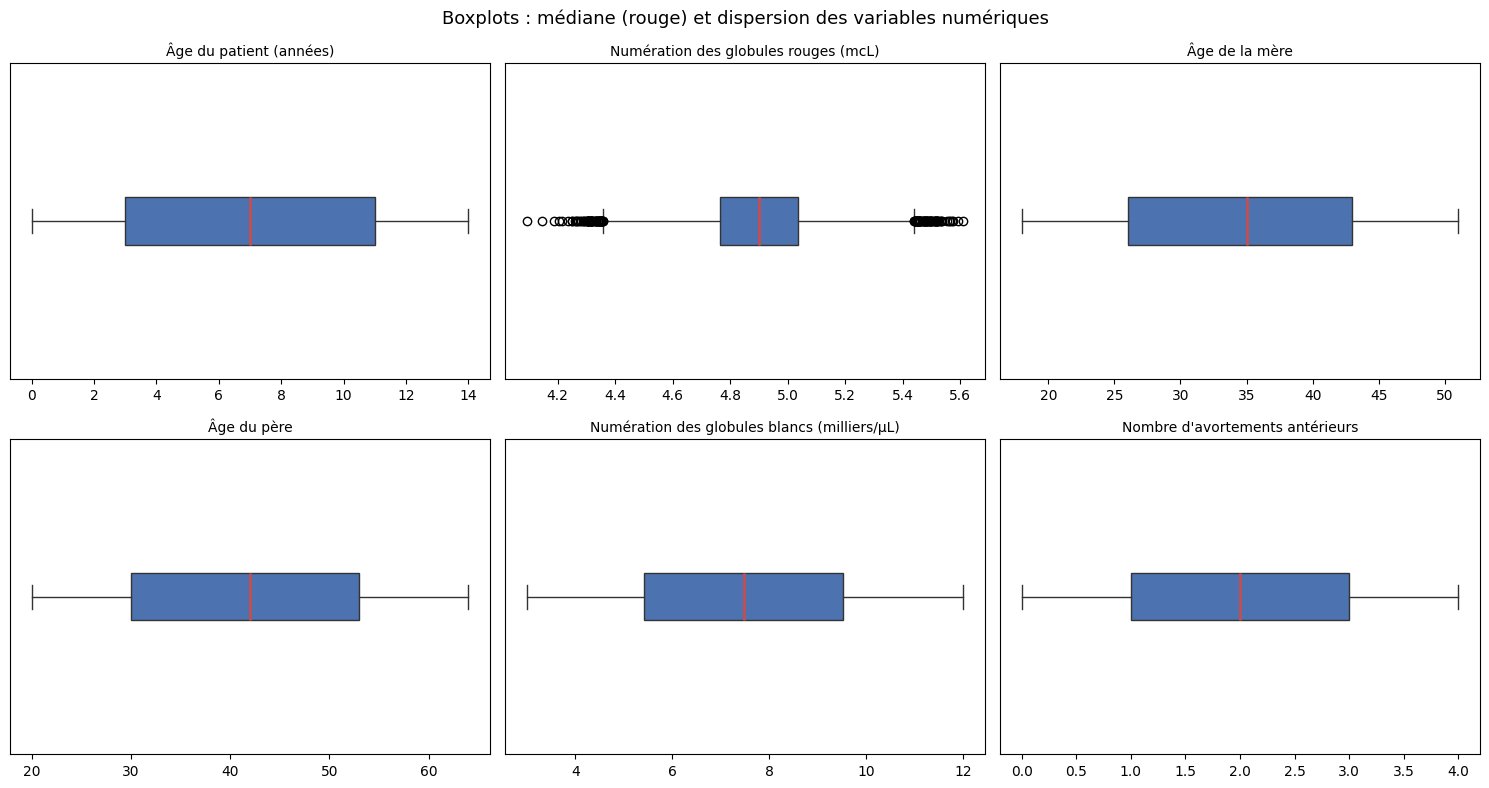

In [32]:
# Boxplots 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, variables_continues):
    donnees = df[col].dropna()
    ax.boxplot(donnees, vert=False, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", color="#333333"),
               medianprops=dict(color="#C44E52", linewidth=2),
               whiskerprops=dict(color="#333333"),
               capprops=dict(color="#333333"))
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])

fig.suptitle("Boxplots : médiane (rouge) et dispersion des variables numériques", fontsize=13)
plt.tight_layout()
plt.show()

La boîte contient la moitié des patients les plus au centre, le trait rouge est la médiane, les moustaches montrent l'étendue, un point isolé au-delà des moustaches est une valeur aberrante (outlier).

La plupart des variables (âge de l'enfant, âge de la mère, âge du père, globules blancs, nombre d'avortements) n'ont aucun outlier, leurs boîtes sont symétriques et bien centrées.

Seule la numération des globules rouges présente des valeurs atypiques, environ 130 patients soit 0,7 %, réparties des deux côtés de la boîte. Ces valeurs restent médicalement plausibles de 4,09 à 5,61 à peine au-delà des bornes normales 4,36 et 5,44, ce sont des variations naturelles et non des erreurs de saisie.

Pour conclure il n'y a qu'un seul petit groupe d'outliers, léger et réaliste, on peut donc les conserver, les supprimer ferait perdre de vrais patients sans améliorer le modèle.


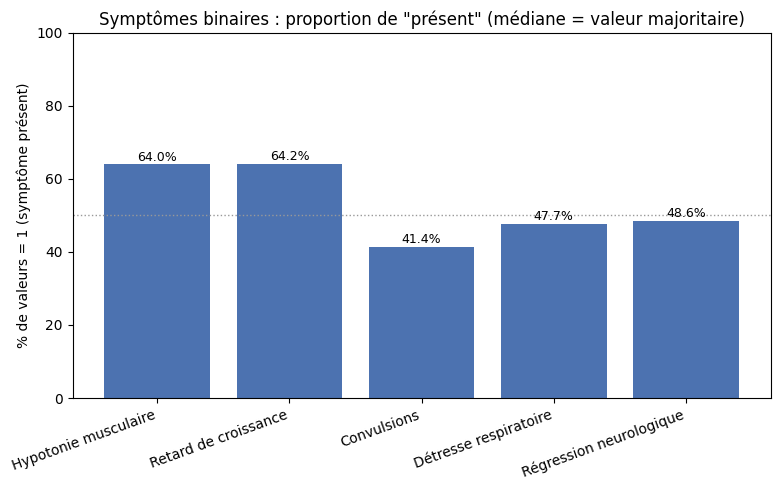

In [33]:
# Symptômes cliniques
symptom_cols = ['Hypotonie musculaire', 'Retard de croissance', 'Convulsions', 'Détresse respiratoire', 'Régression neurologique']
proportions = df[symptom_cols].apply(lambda s: s.dropna().mean() * 100)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(proportions.index, proportions.values, color="#4C72B0")
ax.axhline(50, color="#999999", linestyle=":", linewidth=1)
for bar, val in zip(bars, proportions.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%", ha="center", fontsize=9)

ax.set_ylabel("% de valeurs = 1 (symptôme présent)")
ax.set_ylim(0, 100)
ax.set_title("Symptômes binaires : proportion de \"présent\" (médiane = valeur majoritaire)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Chaque barre est le pourcentage d'enfants qui présentent un symptôme. 

La ligne pointillée marque le repère des 50 %.

Symptômes les plus fréquents est le retard de croissance et hypotonie musculaire qui est présent chez environ 2 enfants sur 3.

Les symptômes les plus rares sont les convulsions, la détresse respiratoire et la régression neurologique représentant environ 1 enfant sur 2 ou moins.

En clair aucun symptôme n'est présent chez tout le monde ni absent chez tout le monde, ils sont donc utiles pour distinguer les maladies 

In [34]:
target_cols = ['Sous-classe diagnostique']
numeric_cols = df.drop(columns=target_cols).select_dtypes(include='number').columns
categorical_cols = df.drop(columns=target_cols).select_dtypes(include='object').columns

# Rapport avant imputation : nombre et % de valeurs manquantes par variable, et valeur utilisée pour l'imputation
nb_manquants = df[numeric_cols.tolist() + categorical_cols.tolist()].isnull().sum()
pct_manquants = (nb_manquants / len(df) * 100).round(2)

valeur_imputation = {}
for col in numeric_cols:
    valeur_imputation[col] = round(df[col].median(), 2)
for col in categorical_cols:
    valeur_imputation[col] = 'Inconnu'

rapport_imputation = pd.DataFrame({
    'Nb valeurs manquantes': nb_manquants,
    '% manquant': pct_manquants,
    'Valeur imputée': pd.Series(valeur_imputation),
}).sort_values('Nb valeurs manquantes', ascending=False)

rapport_imputation = rapport_imputation[rapport_imputation['Nb valeurs manquantes'] > 0]
print(f"{len(rapport_imputation)} variables imputées sur {len(numeric_cols) + len(categorical_cols)} variables explicatives\n")
print(rapport_imputation)

# Application de l'imputation
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna('Inconnu')

df.isnull().sum()

17 variables imputées sur 29 variables explicatives

                                                    Nb valeurs manquantes  \
Âge de la mère                                                       4925   
Âge du père                                                          4862   
Antécédent de toxicomanie                                            1802   
Numération des globules blancs (milliers/µL)                         1786   
Fréquence respiratoire                                               1781   
Sexe                                                                 1767   
Antécédent d'exposition aux radiations (rayons X)                    1763   
Lieu de naissance                                                    1762   
Malformations congénitales                                           1760   
Antécédents d'anomalies lors de grossesses préc...                   1756   
Antécédent de maladie maternelle grave                               1747   
Nombre d'avortements an

Âge du patient (années)                                   0
Gène maternel                                             0
Gène paternel                                             0
Numération des globules rouges (mcL)                      0
Âge de la mère                                            0
Âge du père                                               0
Fréquence respiratoire                                    0
Fréquence cardiaque                                       0
Sexe                                                      0
Asphyxie à la naissance                                   0
Lieu de naissance                                         0
Prise d'acide folique périconceptionnelle                 0
Antécédent de maladie maternelle grave                    0
Antécédent d'exposition aux radiations (rayons X)         0
Antécédent de toxicomanie                                 0
Conception assistée (FIV/PMA)                             0
Antécédents d'anomalies lors de grossess

Dans les données certaines cases sont vides.

Un modèle de machine learning ne sait pas travailler avec des trous il faut donc les remplir.

Pour les chiffres j'utilise la médiane, c'est-à-dire la valeur du milieu quand on range tout dans l'ordre. 

On la préfère à la moyenne car elle n'est pas déformée par les valeurs extrêmes : Par exemple pour les âges 5, 6, 7, 90 la moyenne est tirée vers le haut (23) par le 90 alors que la médiane reste à 7 c'est plus réaliste. Je met donc une valeur typique qui ne fausse pas la colonne.

Pour le texte on ne peut pas calculer de médiane j'ai écrit simplement "Inconnu" plutôt que d'inventer une réponse (dire "garçon" alors qu'on ne sait pas), je reste honnête et "je ne sais pas" devient une catégorie à part entière.

On remplit toute la colonne avec la même valeur car c'est la méthode la plus simple et la plus transparente. Elle ne crée pas de fausse information, elle donne toujours le même résultat si je relance le code et elle est facile à justifier (les cases vides ont été remplies par la valeur centrale de chaque variable).


<a id="sec-2-2"></a>
## 5 Export du dataset nettoyé

In [35]:
df.to_csv('disorders_nettoye_v2.csv', index=False)
print(f"Export terminé : disorders_nettoye_v2.csv ({df.shape[0]} lignes, {df.shape[1]} colonnes)")

Export terminé : disorders_nettoye_v2.csv (18943 lignes, 30 colonnes)
